<a href="https://colab.research.google.com/github/rahulg202/loan-default-prediction/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **EXPLORATORY ANALYSIS**

**1. Loan Outcomes**

In [ ]:
loan_outcomes.head()

,user_id,application_at,loan_outcome
0,1,2017-08-14 09:08:50.000000,defaulted
1,2,2016-05-17 10:10:12.447976,repaid
2,3,2016-10-20 10:07:20.459081,defaulted
3,4,2017-01-13 13:03:34.000000,defaulted
4,5,2016-11-03 15:41:39.124610,repaid


In [ ]:
loan_outcomes.isnull().sum()

,0
user_id,0
application_at,0
loan_outcome,0


In [ ]:
loan_outcomes.describe(include='object')

,loan_outcome
count,400
unique,2
top,defaulted
freq,200


In [ ]:
count=loan_outcomes['loan_outcome'].value_counts()
count

,count
loan_outcome,
defaulted,200
repaid,200


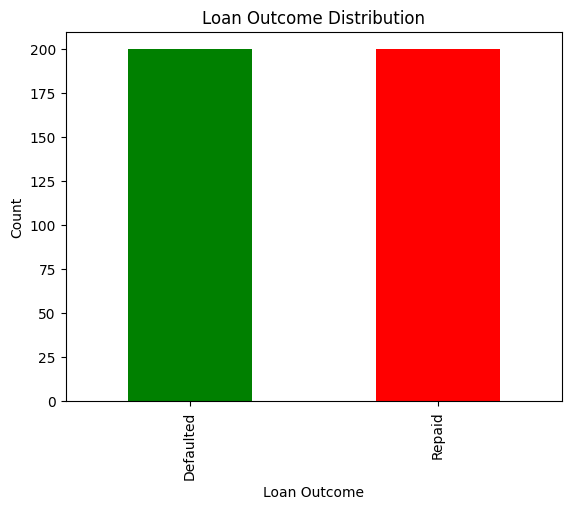

In [ ]:
count.plot(kind='bar', title='Loan Outcome Distribution', color=['green', 'red'])
plt.xlabel('Loan Outcome')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Defaulted', 'Repaid'])
plt.show()

<ipython-input-8-ea5345f94e56>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  defaults_df['application_at'] = pd.to_datetime(defaults_df['application_at'])
<ipython-input-8-ea5345f94e56>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  defaults_df['year'] = defaults_df['application_at'].dt.year


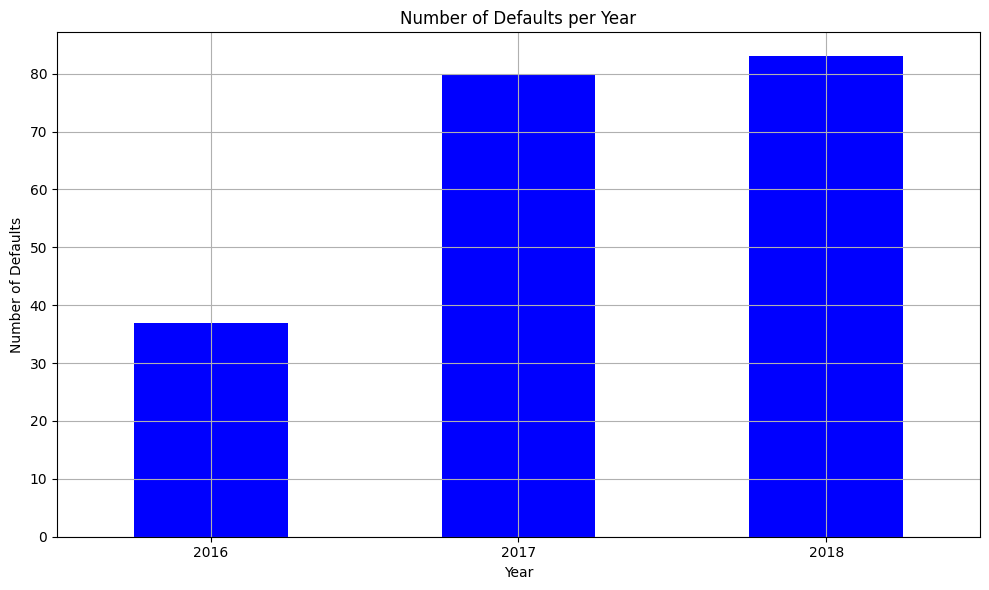

In [ ]:
defaults_df = loan_outcomes[loan_outcomes['loan_outcome'] == 'defaulted']
defaults_df['application_at'] = pd.to_datetime(defaults_df['application_at'])
defaults_df['year'] = defaults_df['application_at'].dt.year
defaults_per_year = defaults_df.groupby('year').size()

plt.figure(figsize=(10, 6))
defaults_per_year.plot(kind='bar', color='b')
plt.title('Number of Defaults per Year')
plt.xlabel('Year')
plt.ylabel('Number of Defaults')
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

**2. GPS Fixes**

In [ ]:
gps_fixes.isnull().sum()

,0
gps_fix_at,0
server_upload_at,0
longitude,0
latitude,0
accuracy,0
altitude,0
bearing,0
location_provider,0
user_id,0


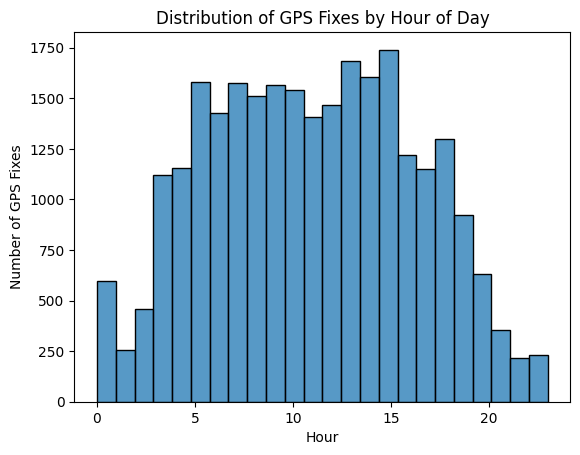

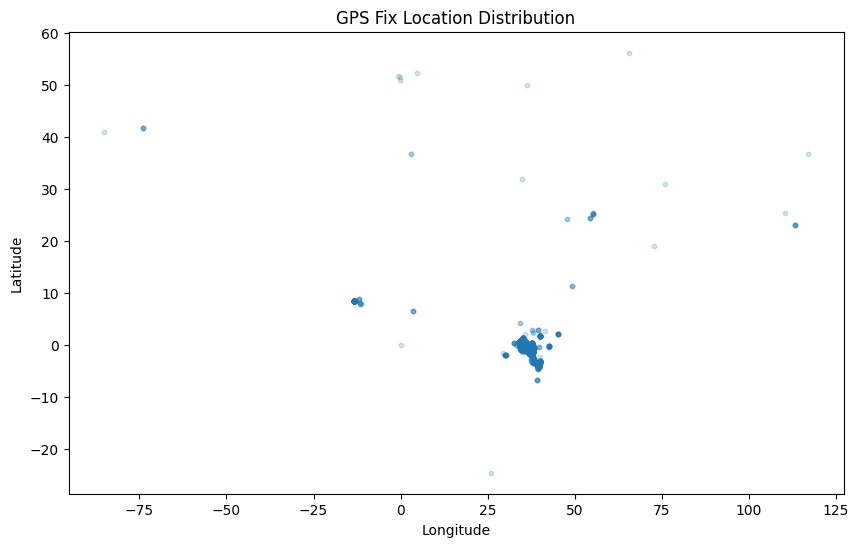

In [ ]:
# Convert gps_fix_at to datetime
gps_fixes['gps_fix_at'] = pd.to_datetime(gps_fixes['gps_fix_at'])

# Distribution of fixes by hour
gps_fixes['hour'] = gps_fixes['gps_fix_at'].dt.hour
sns.histplot(gps_fixes['hour'], bins=24, kde=False)
plt.title('Distribution of GPS Fixes by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of GPS Fixes')
plt.show()

# Spatial scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(gps_fixes['longitude'], gps_fixes['latitude'], alpha=0.2, s=10)
plt.title('GPS Fix Location Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


**3. User Attributes**

In [ ]:
user_attributes.isnull().sum()

,0
user_id,0
age,0
cash_incoming_30days,0


In [ ]:
user_attributes.describe()

,user_id,age,cash_incoming_30days
count,400.000000,400.000000,400.000000
mean,200.500000,36.487500,7896.301075
std,115.614301,13.243236,7037.481340
min,1.000000,18.000000,11.900000
25%,100.750000,27.000000,2602.472500
50%,200.500000,34.000000,6004.240000
75%,300.250000,44.000000,10989.405000
max,400.000000,105.000000,41657.810000


<Axes: title={'center': 'Age Distribution'}, ylabel='Frequency'>

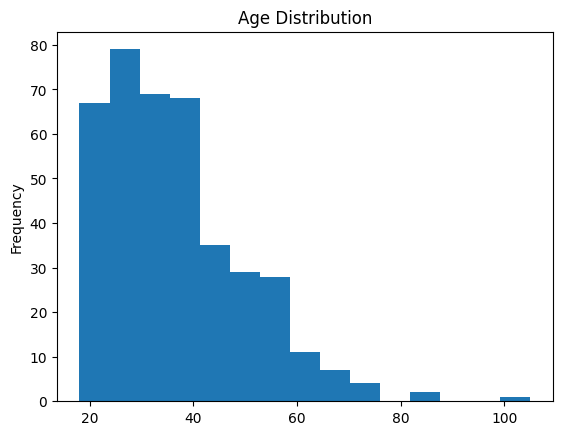

In [ ]:
# Age distribution
user_attributes['age'].plot(kind='hist', bins=15, title='Age Distribution')

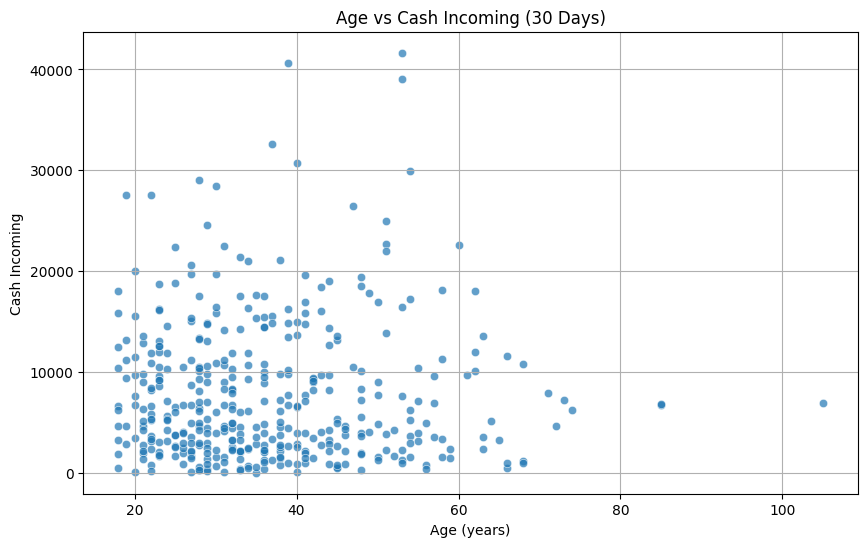

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=user_attributes, x='age', y='cash_incoming_30days', alpha=0.7)
plt.title('Age vs Cash Incoming (30 Days)')
plt.xlabel('Age (years)')
plt.ylabel('Cash Incoming')
plt.grid(True)
plt.show()


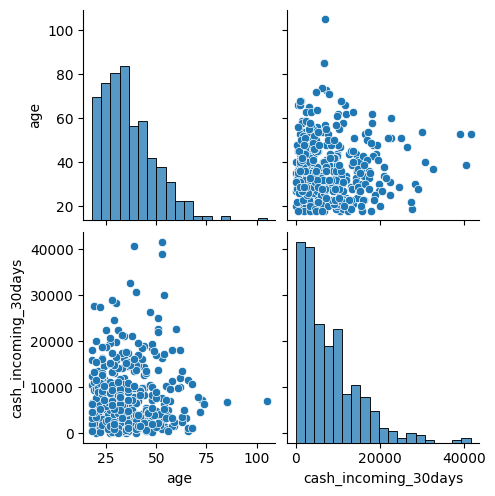

In [ ]:
sns.pairplot(user_attributes[['age', 'cash_incoming_30days']])
plt.show()

<Axes: title={'center': 'Cash Incoming Distribution'}, ylabel='Frequency'>

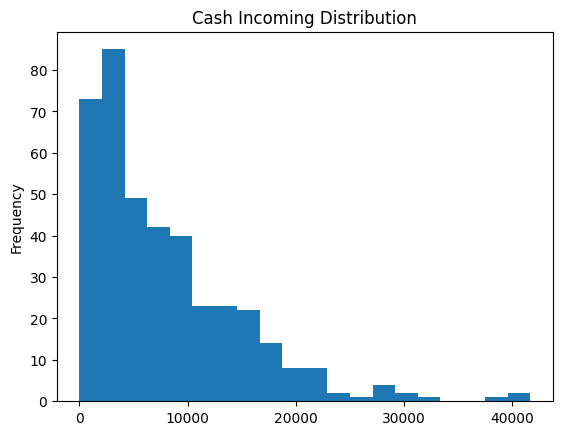

In [ ]:
# Distribution of cash incoming in the last 30 days
user_attributes['cash_incoming_30days'].plot(kind='hist', bins=20, title='Cash Incoming Distribution')

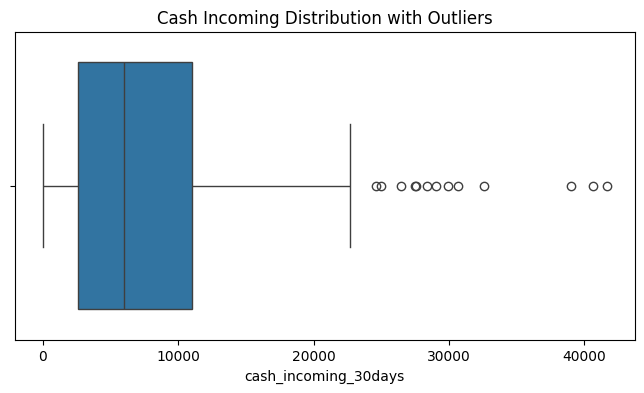

In [ ]:
# Boxplot to analyze outliers in cash incoming
plt.figure(figsize=(8, 4))
sns.boxplot(x='cash_incoming_30days', data=user_attributes)
plt.title('Cash Incoming Distribution with Outliers')
plt.show()

In [ ]:
cols = ['age', 'cash_incoming_30days']
skewness = user_attributes[cols].skew()

print(f"\nSkewness in dataset:")
print(skewness)


Skewness in dataset:
age                     1.118934
cash_incoming_30days    1.585605
dtype: float64
